# Анализ последних запусков ex1_v4

Дата анализа: **7 октября 2026 года**.

Цель — проверить не только формальную accuracy, но и то, реагируют ли модели на истинную гипотезу, prior, знак $\Delta BIC$, силу свидетельств и порядок предъявления гипотез. За основу взята структура ноутбука `ex1_v3_short_analysis.ipynb`.

Для основного сравнения ниже автоматически выбирается **последний завершённый** запуск каждой модели. Все завершённые повторы дополнительно используются для проверки воспроизводимости; незавершённые каталоги не смешиваются с результатами.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)
plt.style.use("seaborn-v0_8-whitegrid")

start = Path.cwd().resolve()
project_root = next(
    (p for p in [start, *start.parents] if (p / "outputs" / "runs" / "ex1_v4").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Не найдена папка outputs/runs/ex1_v4")

runs_dir = project_root / "outputs" / "runs" / "ex1_v4"
previous_runs_dir = project_root / "outputs" / "runs" / "ex1_v3"


## 1. Состав и техническая полнота запусков

В `ex1_v4` есть два полных запуска 0.6B, один полный запуск 4B-AWQ и один пустой каталог прерванной попытки 4B-AWQ. Основной анализ не использует прерванную попытку.


In [2]:
run_infos = []
run_frames = {}

for run_dir in sorted(p for p in runs_dir.iterdir() if p.is_dir()):
    manifest_path = run_dir / "manifest.json"
    metrics_path = run_dir / "metrics.json"
    responses_path = run_dir / "responses.jsonl"
    has_core_files = all(p.exists() for p in [manifest_path, metrics_path, responses_path])

    if not has_core_files:
        inferred_model = "qwen3-4b-awq" if "4b_awq" in run_dir.name else "qwen3-0.6b"
        run_infos.append({
            "run_id": run_dir.name,
            "model": inferred_model,
            "status": "прерван до сохранения отчёта",
            "planned": np.nan,
            "completed": 0,
            "failed": np.nan,
            "invalid": np.nan,
            "duration_min": np.nan,
            "finished_at": pd.NaT,
            "run_dir": run_dir,
        })
        continue

    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    responses = pd.read_json(responses_path, lines=True)
    started = pd.to_datetime(manifest["started_at"], format="%Y%m%dT%H%M%SZ", utc=True)
    finished = pd.to_datetime(manifest["finished_at"], format="%Y%m%dT%H%M%SZ", utc=True)
    complete = (
        metrics["completed"] == metrics["total_planned"]
        and len(responses) == metrics["completed"]
        and metrics["failed"] == 0
        and metrics["invalid_responses"] == 0
    )
    run_infos.append({
        "run_id": run_dir.name,
        "model": metrics["model"],
        "status": "полный" if complete else "неполный",
        "planned": metrics["total_planned"],
        "completed": metrics["completed"],
        "failed": metrics["failed"],
        "invalid": metrics["invalid_responses"],
        "duration_min": (finished - started).total_seconds() / 60,
        "finished_at": finished,
        "run_dir": run_dir,
        "metrics": metrics,
        "manifest": manifest,
    })
    run_frames[run_dir.name] = responses

quality = pd.DataFrame([
    {k: v for k, v in info.items() if k not in {"run_dir", "metrics", "manifest"}}
    for info in run_infos
]).sort_values("run_id").reset_index(drop=True)
display(quality.drop(columns="finished_at").round({"duration_min": 1}))

complete_infos = [info for info in run_infos if info["status"] == "полный"]
latest_infos = {
    model: max(
        (info for info in complete_infos if info["model"] == model),
        key=lambda info: info["finished_at"],
    )
    for model in sorted({info["model"] for info in complete_infos})
}

metrics_by_model = {model: info["metrics"] for model, info in latest_infos.items()}
latest_frames = []
for model, info in latest_infos.items():
    frame = run_frames[info["run_id"]].copy()
    frame["model"] = model
    frame["selected_run"] = info["run_id"]
    latest_frames.append(frame)
all_responses = pd.concat(latest_frames, ignore_index=True)

print("Выбранные последние полные запуски:")
for model, info in latest_infos.items():
    print(f"  {model}: {info['run_id']}")


Выбранные последние полные запуски:
  qwen3-0.6b: ex1_qwen3_06b_v4_20261007T115433Z_5b4db7f8
  qwen3-4b-awq: ex1_qwen3_4b_awq_v4_20261007T121225Z_1c1239e7


,run_id,model,status,planned,completed,failed,invalid,duration_min
0,ex1_qwen3_06b_v4_20261007T111849Z_fd574d8f,qwen3-0.6b,полный,2400.0,2400,0.0,0.0,9.3
1,ex1_qwen3_06b_v4_20261007T115433Z_5b4db7f8,qwen3-0.6b,полный,2400.0,2400,0.0,0.0,9.4
2,ex1_qwen3_4b_awq_v4_20261007T120710Z_ba2cfec0,qwen3-4b-awq,прерван до сохранения отчёта,NaN,0,NaN,NaN,NaN
3,ex1_qwen3_4b_awq_v4_20261007T121225Z_1c1239e7,qwen3-4b-awq,полный,2400.0,2400,0.0,0.0,38.6


Оба выбранных запуска содержат по 2400 валидных ответов без failures. Последний 0.6B занял около 9 минут, 4B-AWQ — около 39 минут; увеличение модели примерно в четыре раза увеличило время, но, как показано ниже, не улучшило поведение.

### Что фактически изменилось относительно ex1_v3

Числовой стимул не изменился: поля, которые попадают в пользовательскую часть prompt (`xs`, observations, SSE, BIC, $\Delta BIC$, likelihood), совпадают во всех 1200 строках. В датасете v4 заполнено только служебное поле `calibrated_evidence_strength` у 600 строк H0; оно не включается в сообщение модели.

При этом **system prompt действительно был усилен**. Сохранённый `resolver_config.yaml` показывает, что в v4 явно добавлены: правило «меньший BIC лучше», корректная интерпретация знака $\Delta BIC$, объяснение вложенности H0 в H1 и прямое предупреждение не выбирать H1 только по меньшей SSE или положительному `log_likelihood_ratio`. Следовательно, v4 — это prompt-интервенция на тех же числовых данных, а не просто идентичный повтор. Ниже важно проверить, помогла ли эта интервенция.


In [3]:
v3_data = pd.read_json(project_root / "data" / "generated" / "ex1_v3" / "dataset.jsonl", lines=True)
v4_data = pd.read_json(project_root / "data" / "generated" / "ex1_v4" / "dataset.jsonl", lines=True)

prompt_visible_fields = [
    "xs", "observations", "sse_h0", "sse_h1", "bic_h0", "bic_h1",
    "delta_bic", "log_likelihood_h0", "log_likelihood_h1", "log_likelihood_ratio",
]

def values_equal(left, right):
    if np.isscalar(left) and np.isscalar(right) and pd.isna(left) and pd.isna(right):
        return True
    return left == right

changed_counts = {
    column: int(sum(not values_equal(a, b) for a, b in zip(v3_data[column], v4_data[column])))
    for column in v3_data.columns
}
changed_counts = {k: v for k, v in changed_counts.items() if v}

v3_resolver_path = sorted(previous_runs_dir.glob("*4b_awq*/resolver_config.yaml"))[-1]
v4_resolver_path = latest_infos["qwen3-4b-awq"]["run_dir"] / "resolver_config.yaml"
v3_resolver = yaml.safe_load(v3_resolver_path.read_text(encoding="utf-8"))
v4_resolver = yaml.safe_load(v4_resolver_path.read_text(encoding="utf-8"))
v3_system_prompt = v3_resolver["system_prompt"]
v4_system_prompt = v4_resolver["system_prompt"]

comparison = pd.DataFrame([
    {"проверка": "число строк", "v3": len(v3_data), "v4": len(v4_data)},
    {
        "проверка": "строк с изменением model-facing полей",
        "v3": "—",
        "v4": int(sum(
            any(not values_equal(v3_data.at[i, c], v4_data.at[i, c]) for c in prompt_visible_fields)
            for i in range(len(v3_data))
        )),
    },
    {
        "проверка": "изменённые поля",
        "v3": "—",
        "v4": ", ".join(f"{k}: {v}" for k, v in changed_counts.items()),
    },
    {
        "проверка": "system prompt совпадает",
        "v3": "—",
        "v4": v3_system_prompt == v4_system_prompt,
    },
    {
        "проверка": "явное предупреждение про log_likelihood_ratio",
        "v3": "не является достаточным основанием" in v3_system_prompt,
        "v4": "не является достаточным основанием" in v4_system_prompt,
    },
])
display(comparison)


,проверка,v3,v4
0,число строк,1200,1200
1,строк с изменением model-facing полей,—,0
2,изменённые поля,—,calibrated_evidence_strength: 600
3,system prompt совпадает,—,False
4,явное предупреждение про log_likelihood_ratio,False,True


## 2. Главный результат: обе модели выродились в константный классификатор H1

При сбалансированных H0/H1 точность 50% выглядит как случайный уровень, но причина конкретнее: модели практически не классифицируют наблюдения, а всегда возвращают один и тот же класс.


,model,prior,n,"H1, %","accuracy, %","balanced accuracy, %","совпадение с ожидаемым решением, %"
0,qwen3-0.6b,neutral,1200,100.0,50.0,50.0,39.83
1,qwen3-0.6b,wrong,1200,100.0,50.0,50.0,75.67
2,qwen3-4b-awq,neutral,1200,100.0,50.0,50.0,39.83
3,qwen3-4b-awq,wrong,1200,100.0,50.0,50.0,75.67


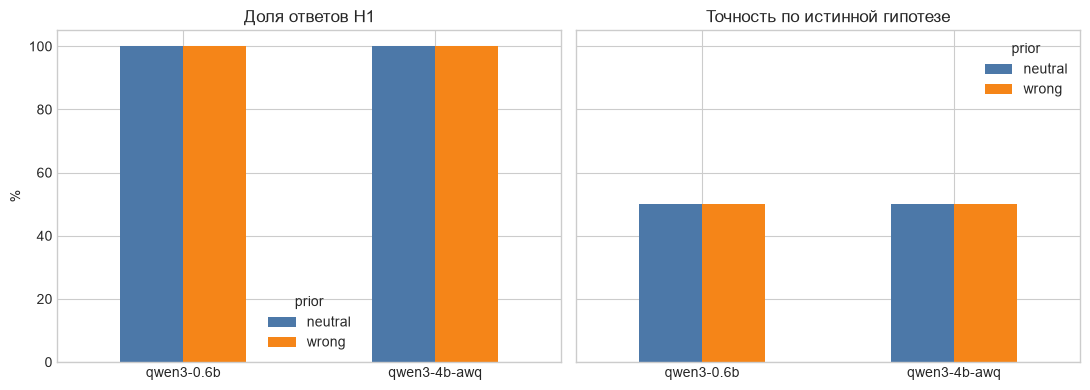

In [4]:
condition_rows = []
for model, m in metrics_by_model.items():
    for prior, values in m["conditions"].items():
        condition_rows.append({
            "model": model,
            "prior": prior,
            "n": values["n"],
            "H1, %": 100 * values["p_h1"],
            "accuracy, %": 100 * values["accuracy"],
            "balanced accuracy, %": 100 * values["balanced_accuracy"],
            "совпадение с ожидаемым решением, %": 100 * values["p_expected_choice_matches"],
        })

conditions = pd.DataFrame(condition_rows).sort_values(["model", "prior"])
display(conditions.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, metric, title in zip(
    axes,
    ["H1, %", "accuracy, %"],
    ["Доля ответов H1", "Точность по истинной гипотезе"],
):
    conditions.pivot(index="model", columns="prior", values=metric).plot(
        kind="bar", ax=ax, color=["#4C78A8", "#F58518"]
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("%")
    ax.set_ylim(0, 105)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="prior")
plt.tight_layout()
plt.show()


В последних запусках обе модели выдали **2400/2400 ответов H1**. Отсюда автоматически следуют 100% accuracy на истинной H1, 0% на истинной H0 и ровно 50% в среднем. Ни одинаковая общая accuracy, ни отсутствие разницы между моделями не означают, что обе модели одинаково хорошо рассуждают: это совпадение двух одинаковых константных стратегий.


In [5]:
truth = (
    all_responses
    .groupby(["model", "prior", "right_hypothesis"], as_index=False)
    .agg(
        n=("answer", "size"),
        actual_h1=("answer", lambda s: 100 * s.eq("H1").mean()),
        accuracy=("is_right", lambda s: 100 * s.mean()),
        expected_h1=("expected_choice", lambda s: 100 * s.eq("H1").mean()),
        mean_expected_p_h1=("expected_p_h1", lambda s: 100 * s.mean()),
    )
)
display(truth.round(2))


,model,prior,right_hypothesis,n,actual_h1,accuracy,expected_h1,mean_expected_p_h1
0,qwen3-0.6b,neutral,H0,600,100.0,0.0,3.83,20.30
1,qwen3-0.6b,neutral,H1,600,100.0,100.0,75.83,74.84
2,qwen3-0.6b,wrong,H0,600,100.0,0.0,100.00,65.97
3,qwen3-0.6b,wrong,H1,600,100.0,100.0,51.33,51.91
4,qwen3-4b-awq,neutral,H0,600,100.0,0.0,3.83,20.30
5,qwen3-4b-awq,neutral,H1,600,100.0,100.0,75.83,74.84
6,qwen3-4b-awq,wrong,H0,600,100.0,0.0,100.00,65.97
7,qwen3-4b-awq,wrong,H1,600,100.0,100.0,51.33,51.91


## 3. Данные различимы, но модели не используют решающий сигнал

Это не похоже на ситуацию, в которой H0 и H1 невозможно различить. На 1200 уникальных наборах знак $\Delta BIC$ при нейтральном prior указывает истинную гипотезу в **1032 случаях (86%)**: 577/600 для H0 и 455/600 для H1. Нормативное правило на основе prior и $\Delta BIC$ тем самым заметно лучше фактических 50%.

Ключевое противоречие: в 722/1200 уникальных наборов $\Delta BIC<0$ и BIC поддерживает H0, однако модель всё равно выбирает H1. Значит, плоскую кривую нельзя объяснить только недостаточной силой данных.


In [6]:
reference_model = sorted(latest_infos)[-1]
reference = all_responses[all_responses["model"].eq(reference_model)].copy()
unique_data = reference.drop_duplicates("dataset_id")

diagnostics = pd.DataFrame([
    {
        "проверка": "ΔBIC поддерживает истинную гипотезу",
        "число": int(np.where(
            unique_data["right_hypothesis"].eq("H1"),
            unique_data["delta_bic"].gt(0),
            unique_data["delta_bic"].lt(0),
        ).sum()),
        "из": len(unique_data),
    },
    {
        "проверка": "ΔBIC < 0 (BIC поддерживает H0)",
        "число": int(unique_data["delta_bic"].lt(0).sum()),
        "из": len(unique_data),
    },
    {
        "проверка": "SSE у H1 меньше SSE у H0",
        "число": int(unique_data["sse_h1"].lt(unique_data["sse_h0"]).sum()),
        "из": len(unique_data),
    },
    {
        "проверка": "log-likelihood ratio > 0",
        "число": int(unique_data["log_likelihood_ratio"].gt(0).sum()),
        "из": len(unique_data),
    },
])
diagnostics["доля, %"] = 100 * diagnostics["число"] / diagnostics["из"]
display(diagnostics.round({"доля, %": 2}))

neutral = reference[reference["prior"].eq("neutral")]
neutral_summary = pd.DataFrame([
    {
        "правило": "фактический ответ модели",
        "accuracy, %": 100 * neutral["is_right"].mean(),
    },
    {
        "правило": "ожидаемый выбор по prior + ΔBIC/2",
        "accuracy, %": 100 * neutral["expected_choice"].eq(neutral["right_hypothesis"]).mean(),
    },
])
display(neutral_summary.round(2))


,проверка,число,из,"доля, %"
0,ΔBIC поддерживает истинную гипотезу,1032,1200,86.00
1,ΔBIC < 0 (BIC поддерживает H0),722,1200,60.17
2,SSE у H1 меньше SSE у H0,1200,1200,100.00
3,log-likelihood ratio > 0,1200,1200,100.00


,правило,"accuracy, %"
0,фактический ответ модели,50.0
1,ожидаемый выбор по prior + ΔBIC/2,86.0


### Наиболее вероятный механизм ошибки

H0 вложена в H1, а H1 имеет дополнительный параметр `alpha`, поэтому после подгонки на тех же данных H1 во всех 1200 наборах получила меньшую SSE и больший log-likelihood. Соответственно `log_likelihood_ratio` положителен во всех случаях — в том числе когда BIC после штрафа за сложность уверенно поддерживает H0.

В текущем пользовательском сообщении `log_likelihood_ratio` расположен **последней строкой, после Delta BIC**. Усиленный system prompt v4 прямо предупреждает не выбирать H1 только по этому показателю, однако результат стал даже строго константным. Значит, одной словесной инструкции оказалось недостаточно. Наблюдаемое поведение полностью совместимо с более простым эвристическим правилом «последний показатель положителен → H1» либо «более гибкая модель лучше подогнала данные → H1». Это обоснованная гипотеза о механизме, но не доказательство причинности: для разделения recency bias, label bias и bias в пользу сложной модели нужны абляции.


## 4. Prior должен менять решение, но не меняет ответ модели

Для каждого набора данных есть пара запросов с `neutral` и намеренно ошибочным (`wrong`) prior. При вычислении ожидаемого posterior выбор должен измениться в 724 из 1200 пар. У моделей не изменился ни один ответ.


In [7]:
prior_rows = []
for model, part in all_responses.groupby("model"):
    index = ["dataset_id", "right_hypothesis", "hypothesis_order"]
    actual = part.pivot(index=index, columns="prior", values="answer")
    expected = part.pivot(index=index, columns="prior", values="expected_choice")
    for truth in ["H0", "H1", "all"]:
        if truth == "all":
            actual_part, expected_part = actual, expected
        else:
            mask = actual.index.get_level_values("right_hypothesis") == truth
            actual_part, expected_part = actual.loc[mask], expected.loc[mask]
        prior_rows.append({
            "model": model,
            "истинная гипотеза": truth,
            "пар": len(actual_part),
            "ожидаемых переключений": int((expected_part["neutral"] != expected_part["wrong"]).sum()),
            "фактических переключений": int((actual_part["neutral"] != actual_part["wrong"]).sum()),
        })

prior_sensitivity = pd.DataFrame(prior_rows)
display(prior_sensitivity)


,model,истинная гипотеза,пар,ожидаемых переключений,фактических переключений
0,qwen3-0.6b,H0,600,577,0
1,qwen3-0.6b,H1,600,147,0
2,qwen3-0.6b,all,1200,724,0
3,qwen3-4b-awq,H0,600,577,0
4,qwen3-4b-awq,H1,600,147,0
5,qwen3-4b-awq,all,1200,724,0


Высокое «совпадение с ожидаемым решением» в условии `wrong` (75.67%) здесь вводит в заблуждение. Константный H1 случайно совпадает со всеми 600 ожидаемыми H1 в ветке истинной H0, где ошибочный prior специально направлен в сторону H1, и ещё с 308/600 случаями истинной H1. Это не чувствительность к prior, а следствие распределения ожидаемых меток.


## 5. Сила свидетельств и порядок предъявления

`target_evidence_strength` задана только для ветки истинной H1. Нормативная средняя posterior-вероятность H1 в целом растёт с силой свидетельств и зависит от prior, хотя отдельные соседние уровни не обязаны быть монотонны из-за 50 реализаций на уровень и стохастической калибровки. Фактическая доля H1 остаётся 100% на всех уровнях, поэтому эксперимент не обнаруживает у моделей градиента чувствительности к силе данных.


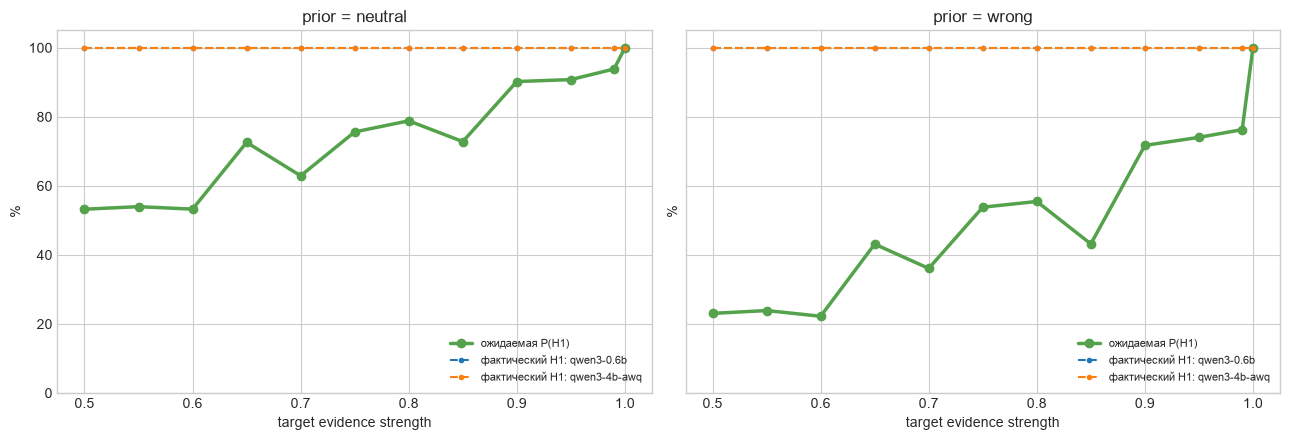

,model,prior,hypothesis_order,n,H1_pct
0,qwen3-0.6b,neutral,H0_H1,600,100.0
1,qwen3-0.6b,neutral,H1_H0,600,100.0
2,qwen3-0.6b,wrong,H0_H1,600,100.0
3,qwen3-0.6b,wrong,H1_H0,600,100.0
4,qwen3-4b-awq,neutral,H0_H1,600,100.0
5,qwen3-4b-awq,neutral,H1_H0,600,100.0
6,qwen3-4b-awq,wrong,H0_H1,600,100.0
7,qwen3-4b-awq,wrong,H1_H0,600,100.0


In [8]:
evidence = (
    all_responses[all_responses["right_hypothesis"].eq("H1")]
    .groupby(["model", "prior", "target_evidence_strength"], as_index=False)
    .agg(
        actual_h1=("answer", lambda s: 100 * s.eq("H1").mean()),
        mean_expected_p_h1=("expected_p_h1", lambda s: 100 * s.mean()),
        expected_h1=("expected_choice", lambda s: 100 * s.eq("H1").mean()),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, prior in zip(axes, ["neutral", "wrong"]):
    part = evidence[evidence["prior"].eq(prior)]
    normative = part.groupby("target_evidence_strength", as_index=False)["mean_expected_p_h1"].mean()
    ax.plot(
        normative["target_evidence_strength"],
        normative["mean_expected_p_h1"],
        marker="o",
        color="#54A24B",
        linewidth=2.5,
        label="ожидаемая P(H1)",
    )
    for model, model_part in part.groupby("model"):
        ax.plot(
            model_part["target_evidence_strength"],
            model_part["actual_h1"],
            marker=".",
            linestyle="--",
            label=f"фактический H1: {model}",
        )
    ax.set_title(f"prior = {prior}")
    ax.set_xlabel("target evidence strength")
    ax.set_ylabel("%")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

order = (
    all_responses
    .groupby(["model", "prior", "hypothesis_order"], as_index=False)
    .agg(n=("answer", "size"), H1_pct=("answer", lambda s: 100 * s.eq("H1").mean()))
)
display(order.round(2))


Контрбалансировка порядка сработала технически, но не диагностически: H1 выбирается и когда стоит первой, и когда стоит второй. При этом метки не переопределяются — H1 всегда остаётся более сложной кубической моделью. Поэтому этот тест исключает простой position bias, но **не** отделяет склонность к самой метке `H1` от склонности к более гибкой формуле.


## 6. Воспроизводимость результата

Константный паттерн устойчив между повтором 0.6B, моделями и версиями v3/v4. Это усиливает вывод о систематической ошибке постановки/эвристики, а не о случайном отклонении одного запуска.


In [9]:
pair_keys = ["dataset_id", "prior", "hypothesis_order", "right_hypothesis"]

def answer_agreement(left, right):
    paired = (
        left.set_index(pair_keys)[["answer"]]
        .join(right.set_index(pair_keys)[["answer"]], lsuffix="_left", rsuffix="_right", how="inner")
    )
    agrees = int(paired["answer_left"].eq(paired["answer_right"]).sum())
    return len(paired), agrees, 100 * agrees / len(paired)

agreement_rows = []
complete_06b = sorted(
    (info for info in complete_infos if info["model"] == "qwen3-0.6b"),
    key=lambda info: info["finished_at"],
)
if len(complete_06b) >= 2:
    n, agrees, pct = answer_agreement(
        run_frames[complete_06b[-2]["run_id"]],
        run_frames[complete_06b[-1]["run_id"]],
    )
    agreement_rows.append({
        "сравнение": "0.6B: два повтора v4",
        "совпало": agrees,
        "из": n,
        "%": pct,
    })

models = sorted(latest_infos)
if len(models) == 2:
    left = run_frames[latest_infos[models[0]]["run_id"]]
    right = run_frames[latest_infos[models[1]]["run_id"]]
    n, agrees, pct = answer_agreement(left, right)
    agreement_rows.append({
        "сравнение": "последние 0.6B и 4B-AWQ",
        "совпало": agrees,
        "из": n,
        "%": pct,
    })

for model in models:
    candidates = []
    for run_dir in previous_runs_dir.iterdir():
        metrics_path = run_dir / "metrics.json"
        responses_path = run_dir / "responses.jsonl"
        if not (metrics_path.exists() and responses_path.exists()):
            continue
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        if metrics["model"] == model:
            candidates.append(run_dir)
    if candidates:
        v3_dir = sorted(candidates)[-1]
        v3_frame = pd.read_json(v3_dir / "responses.jsonl", lines=True)
        v4_frame = run_frames[latest_infos[model]["run_id"]]
        n, agrees, pct = answer_agreement(v3_frame, v4_frame)
        agreement_rows.append({
            "сравнение": f"{model}: v3 vs последний v4",
            "совпало": agrees,
            "из": n,
            "%": pct,
        })

agreement = pd.DataFrame(agreement_rows)
display(agreement.round({"%": 2}))


,сравнение,совпало,из,%
0,0.6B: два повтора v4,2399,2400,99.96
1,последние 0.6B и 4B-AWQ,2400,2400,100.00
2,qwen3-0.6b: v3 vs последний v4,2397,2400,99.88
3,qwen3-4b-awq: v3 vs последний v4,2399,2400,99.96


## Содержательные выводы

1. **Запуски технически корректны, но содержательно неуспешны.** Последние 0.6B и 4B-AWQ полностью завершены, без invalid/failures, однако обе модели отвечают H1 во всех 2400 испытаниях. Точность 50% — артефакт баланса классов.

2. **Проблема не сводится к слабым данным.** При нейтральном prior правило по знаку $\Delta BIC$ даёт 86% правильных решений, тогда как модели дают 50%. В 60.17% уникальных наборов BIC поддерживает H0, но это не отражается в ответах.

3. **Модели не демонстрируют использования prior.** Нормативное решение меняется между `neutral` и `wrong` в 724/1200 пар, фактическое — в 0/1200. Поэтому агрегированное совпадение с `expected_choice`, особенно 75.67% для `wrong`, нельзя интерпретировать как Bayesian sensitivity.

4. **Наиболее правдоподобная причина — конфликт признаков и простая эвристика.** Более общая H1 всегда имеет лучшую SSE и log-likelihood, а положительный `log_likelihood_ratio` стоит последней строкой prompt. Модель, вероятно, следует этому более заметному и всегда однонаправленному сигналу, игнорируя штраф BIC и prior. Дополнительно могут влиять bias к метке H1/более сложной формуле, длинный числовой контекст и отключённое рассуждение (`enable_thinking=False`). По текущим данным эти механизмы нельзя разделить причинно.

5. **Увеличение размера модели не помогло.** 4B-AWQ воспроизводит тот же константный ответ, затрачивая примерно в четыре раза больше времени. Вероятнее всего, сначала нужно исправить/упростить постановку, а уже затем сравнивать размеры моделей.

6. **Усиление system prompt в v4 не исправило ошибку.** Числовые данные остались прежними, но инструкция стала существенно точнее: она объясняет вложенность, знак $\Delta BIC$ и опасность положительного likelihood ratio. Тем не менее ответы остались на 99.88–99.96% согласованы с v3 и в последних запусках стали ровно 100% H1. Это сильный признак того, что дальнейшее наращивание словесных предупреждений без изменения структуры стимула вряд ли поможет.

### Что проверить следующим запуском

- Сделать минимальную абляцию: оставить только prior, $\Delta BIC$ и явно вычисленный `log_posterior_odds_H1 = log(P(H1)/P(H0)) + ΔBIC/2`; поставить итоговый score последней строкой.
- Отдельно убрать SSE, log-likelihood и `log_likelihood_ratio`, затем добавлять их по одному. Это напрямую проверит гипотезу о конфликтующем/последнем признаке.
- Провести label-swap: случайно называть модели `A/B` либо менять соответствие формул меткам. Порядок строк уже контрбалансирован, но семантика H1 как сложной модели остаётся постоянной.
- Добавить несколько демонстраций конфликтных случаев: `log_likelihood_ratio > 0`, но $\Delta BIC < 0$ и правильный ответ H0.
- После исправления prompt сравнить `enable_thinking=False/True` и более крупную модель. Сейчас такой тест вторичен: обе имеющиеся модели используют одну и ту же неадекватную стратегию.
